# Install libraries

In [1]:
!pip install pandas numpy scikit-learn matplotlib seaborn joblib pyarrow xgboost streamlit plotly -q

# Import libraries

In [2]:
import os
import gc
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import pyarrow.parquet as pq

import matplotlib.pyplot as plt
import seaborn as sns

import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    precision_recall_fscore_support
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

BASE_DIR = Path("Dataset")
INPUT_DIR = BASE_DIR / "input"

OUTPUT_DIR = Path("./outputs")
MODEL_DIR = Path("./models")
CM_DIR = OUTPUT_DIR / "confusion_matrices"

for folder in [OUTPUT_DIR, MODEL_DIR, CM_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

# Start with these values. Increase later if stable.
MAX_CLIENTS = 15000
NEGATIVES_PER_POSITIVE = 3
TOP_POPULAR_PRODUCTS = 800
BATCH_SIZE = 300_000

print("BASE exists:", BASE_DIR.exists())
print("INPUT exists:", INPUT_DIR.exists())

BASE exists: True
INPUT exists: True


# Detect files

In [3]:
def find_file_by_keyword(folder, keywords):
    folder = Path(folder)

    for file in folder.iterdir():
        name = file.name.lower()

        if all(k.lower() in name for k in keywords):
            return file

    return None


product_buy_path = find_file_by_keyword(INPUT_DIR, ["product", "buy"])
add_to_cart_path = find_file_by_keyword(INPUT_DIR, ["add", "cart"])
remove_from_cart_path = find_file_by_keyword(INPUT_DIR, ["remove", "cart"])
page_visit_path = find_file_by_keyword(INPUT_DIR, ["page", "visit"])
search_query_path = find_file_by_keyword(INPUT_DIR, ["search"])
product_props_path = find_file_by_keyword(BASE_DIR, ["product", "propert"])

print("product_buy:", product_buy_path)
print("add_to_cart:", add_to_cart_path)
print("remove_from_cart:", remove_from_cart_path)
print("page_visit:", page_visit_path)
print("search_query:", search_query_path)
print("product_properties:", product_props_path)

product_buy: Dataset/input/product_buy.parquet
add_to_cart: Dataset/input/add_to_cart.parquet
remove_from_cart: Dataset/input/remove_from_cart.parquet
page_visit: Dataset/input/page_visit.parquet
search_query: Dataset/input/search_query.parquet
product_properties: Dataset/product_properties.parquet


# Inspect columns without loading full files

In [4]:
def show_columns(path):
    pf = pq.ParquetFile(path)
    cols = pf.schema.names

    print(f"\n{path.name}")
    print(cols)

    return cols


buy_cols = show_columns(product_buy_path)
cart_cols = show_columns(add_to_cart_path)
remove_cols = show_columns(remove_from_cart_path)
visit_cols = show_columns(page_visit_path)
search_cols = show_columns(search_query_path)
props_cols = show_columns(product_props_path)


product_buy.parquet
['client_id', 'timestamp', 'sku']

add_to_cart.parquet
['client_id', 'timestamp', 'sku']

remove_from_cart.parquet
['client_id', 'timestamp', 'sku']

page_visit.parquet
['client_id', 'timestamp', 'url']

search_query.parquet
['client_id', 'timestamp', 'query']

product_properties.parquet
['sku', 'category', 'price', 'name']


# Choose required columns

In [5]:
def detect_client_col(cols):
    for c in cols:
        if c.lower() in ["client_id", "user_id", "customer_id", "client"]:
            return c
    return None


def detect_sku_col(cols):
    for c in cols:
        if c.lower() in ["sku", "product_id", "item_id", "product"]:
            return c
    return None


def detect_timestamp_col(cols):
    for c in cols:
        cl = c.lower()

        if "timestamp" in cl or "time" in cl or "date" in cl:
            return c

    return None


buy_client_col = detect_client_col(buy_cols)
buy_sku_col = detect_sku_col(buy_cols)
buy_time_col = detect_timestamp_col(buy_cols)

print("Buy client column:", buy_client_col)
print("Buy sku column:", buy_sku_col)
print("Buy timestamp column:", buy_time_col)

Buy client column: client_id
Buy sku column: sku
Buy timestamp column: timestamp


# Load only product_buy first

In [6]:
buy_usecols = [buy_client_col, buy_sku_col]

if buy_time_col is not None:
    buy_usecols.append(buy_time_col)

buy_usecols = list(dict.fromkeys(buy_usecols))

buys = pd.read_parquet(product_buy_path, columns=buy_usecols)

rename_map = {
    buy_client_col: "client_id",
    buy_sku_col: "sku"
}

if buy_time_col is not None:
    rename_map[buy_time_col] = "timestamp"

buys = buys.rename(columns=rename_map)

print("buys shape:", buys.shape)
display(buys.head())

buys shape: (1775394, 3)


,client_id,sku,timestamp
0,19433713,649662,2022-06-23 00:12:15
1,11106698,965816,2022-06-23 00:12:25
2,3334023,419981,2022-06-23 00:15:25
3,3334023,1161623,2022-06-23 00:15:25
4,2310948,520725,2022-06-23 00:17:20


# Sample clients

In [7]:
all_clients = buys["client_id"].dropna().unique()

print("Total clients with purchase records:", len(all_clients))

sampled_clients = np.random.default_rng(RANDOM_STATE).choice(
    all_clients,
    size=min(MAX_CLIENTS, len(all_clients)),
    replace=False
)

sampled_clients = set(sampled_clients)

buys = buys[buys["client_id"].isin(sampled_clients)].copy()

gc.collect()

print("Sampled clients:", len(sampled_clients))
print("Filtered buys:", buys.shape)

Total clients with purchase records: 744980
Sampled clients: 15000
Filtered buys: (36247, 3)


# Helper: batch process huge event files

In [8]:
def process_event_counts_in_batches(
    parquet_path,
    sampled_clients,
    event_name,
    needs_sku=True,
    batch_size=500_000
):
    """
    Processes large parquet event files in batches.
    Only keeps rows for sampled clients.

    Returns:
    - event count per client
    - unique sku count per client, if sku exists
    """

    if parquet_path is None:
        print(f"{event_name}: path is None")
        return pd.DataFrame(index=pd.Index(list(sampled_clients), name="client_id"))

    pf = pq.ParquetFile(parquet_path)
    cols = pf.schema.names

    client_col = detect_client_col(cols)
    sku_col = detect_sku_col(cols)

    if client_col is None:
        print(f"{event_name}: no client column found")
        return pd.DataFrame(index=pd.Index(list(sampled_clients), name="client_id"))

    read_cols = [client_col]

    if needs_sku and sku_col is not None:
        read_cols.append(sku_col)

    read_cols = list(dict.fromkeys(read_cols))

    event_counter = Counter()
    sku_sets = defaultdict(set)

    print("\n" + "=" * 80)
    print(f"Processing {event_name}")
    print("File:", parquet_path.name)
    print("Columns:", read_cols)
    print("=" * 80)

    batch_num = 0

    for batch in pf.iter_batches(batch_size=batch_size, columns=read_cols):
        batch_num += 1

        chunk = batch.to_pandas()

        chunk = chunk.rename(columns={client_col: "client_id"})

        if sku_col is not None and sku_col in chunk.columns:
            chunk = chunk.rename(columns={sku_col: "sku"})

        chunk = chunk[chunk["client_id"].isin(sampled_clients)]

        if len(chunk) == 0:
            del chunk
            continue

        counts = chunk["client_id"].value_counts()

        for client, count in counts.items():
            event_counter[client] += int(count)

        if needs_sku and "sku" in chunk.columns:
            grouped = chunk.groupby("client_id")["sku"].unique()

            for client, skus in grouped.items():
                sku_sets[client].update(skus)

        if batch_num % 20 == 0:
            print(f"{event_name}: processed batch {batch_num}")

        del chunk
        gc.collect()

    out = pd.DataFrame(index=pd.Index(list(sampled_clients), name="client_id"))

    out[f"{event_name}_count"] = [
        event_counter.get(client, 0) for client in out.index
    ]

    if needs_sku:
        out[f"{event_name}_unique_skus"] = [
            len(sku_sets.get(client, set())) for client in out.index
        ]

    print(f"{event_name}: completed")
    print(out.head())

    return out

# Process all event files safely

In [9]:
cart_add_features = process_event_counts_in_batches(
    add_to_cart_path,
    sampled_clients,
    event_name="cart_add",
    needs_sku=True,
    batch_size=BATCH_SIZE
)

cart_remove_features = process_event_counts_in_batches(
    remove_from_cart_path,
    sampled_clients,
    event_name="cart_remove",
    needs_sku=True,
    batch_size=BATCH_SIZE
)

page_visit_features = process_event_counts_in_batches(
    page_visit_path,
    sampled_clients,
    event_name="page_visit",
    needs_sku=True,
    batch_size=BATCH_SIZE
)

search_features = process_event_counts_in_batches(
    search_query_path,
    sampled_clients,
    event_name="search",
    needs_sku=False,
    batch_size=BATCH_SIZE
)


Processing cart_add
File: add_to_cart.parquet
Columns: ['client_id', 'sku']
cart_add: completed
           cart_add_count  cart_add_unique_skus
client_id                                      
8880128                 1                     1
19431425                2                     2
17956866                4                     3
15466501                2                     1
15630343                7                     6

Processing cart_remove
File: remove_from_cart.parquet
Columns: ['client_id', 'sku']
cart_remove: completed
           cart_remove_count  cart_remove_unique_skus
client_id                                            
8880128                    0                        0
19431425                   0                        0
17956866                   2                        2
15466501                   1                        1
15630343                   3                        2

Processing page_visit
File: page_visit.parquet
Columns: ['client_id']
page_visit

# Build user features

In [10]:
user_features = pd.DataFrame(index=pd.Index(list(sampled_clients), name="client_id"))

buy_count = buys.groupby("client_id").size()
unique_bought_skus = buys.groupby("client_id")["sku"].nunique()

user_features["buy_count"] = user_features.index.map(buy_count).fillna(0).astype("int32")
user_features["unique_skus_bought"] = user_features.index.map(unique_bought_skus).fillna(0).astype("int32")

user_features = user_features.join(cart_add_features, how="left")
user_features = user_features.join(cart_remove_features, how="left")
user_features = user_features.join(page_visit_features, how="left")
user_features = user_features.join(search_features, how="left")

user_features = user_features.fillna(0)

print("User features shape:", user_features.shape)
display(user_features.head())

User features shape: (15000, 9)


,buy_count,unique_skus_bought,cart_add_count,cart_add_unique_skus,cart_remove_count,cart_remove_unique_skus,page_visit_count,page_visit_unique_skus,search_count
client_id,,,,,,,,,
8880128,2,2,1,1,0,0,2,0,6
19431425,1,1,2,2,0,0,45,0,3
17956866,2,2,4,3,2,2,29,0,10
15466501,1,1,2,1,1,1,64,0,2
15630343,5,4,7,6,3,2,46,0,19


In [11]:
# Avoid division by zero using +1
user_features["cart_to_buy_ratio"] = (
    user_features["cart_add_count"] / (user_features["buy_count"] + 1)
)

user_features["remove_to_cart_ratio"] = (
    user_features["cart_remove_count"] / (user_features["cart_add_count"] + 1)
)

user_features["visit_to_buy_ratio"] = (
    user_features["page_visit_count"] / (user_features["buy_count"] + 1)
)

user_features["search_to_buy_ratio"] = (
    user_features["search_count"] / (user_features["buy_count"] + 1)
)

user_features["cart_unique_ratio"] = (
    user_features["cart_add_unique_skus"] / (user_features["cart_add_count"] + 1)
)

user_features["visit_unique_ratio"] = (
    user_features["page_visit_unique_skus"] / (user_features["page_visit_count"] + 1)
)

# Behaviour intensity score
user_features["engagement_score"] = (
    user_features["buy_count"] * 5
    + user_features["cart_add_count"] * 3
    + user_features["page_visit_count"] * 1
    + user_features["search_count"] * 2
    - user_features["cart_remove_count"] * 1
)

# Product exploration score
user_features["exploration_score"] = (
    user_features["unique_skus_bought"]
    + user_features["cart_add_unique_skus"]
    + user_features["page_visit_unique_skus"]
)

user_features = user_features.replace([np.inf, -np.inf], 0)
user_features = user_features.fillna(0)

print("User features after ratios:", user_features.shape)
display(user_features.head())

User features after ratios: (15000, 17)


,buy_count,unique_skus_bought,cart_add_count,cart_add_unique_skus,cart_remove_count,cart_remove_unique_skus,page_visit_count,page_visit_unique_skus,search_count,cart_to_buy_ratio,remove_to_cart_ratio,visit_to_buy_ratio,search_to_buy_ratio,cart_unique_ratio,visit_unique_ratio,engagement_score,exploration_score
client_id,,,,,,,,,,,,,,,,,
8880128,2,2,1,1,0,0,2,0,6,0.333333,0.000000,0.666667,2.000000,0.500000,0.0,27,3
19431425,1,1,2,2,0,0,45,0,3,1.000000,0.000000,22.500000,1.500000,0.666667,0.0,62,3
17956866,2,2,4,3,2,2,29,0,10,1.333333,0.400000,9.666667,3.333333,0.600000,0.0,69,5
15466501,1,1,2,1,1,1,64,0,2,1.000000,0.333333,32.000000,1.000000,0.333333,0.0,78,2
15630343,5,4,7,6,3,2,46,0,19,1.166667,0.375000,7.666667,3.166667,0.750000,0.0,127,10


# Load product properties safely

In [12]:
props_cols = pq.ParquetFile(product_props_path).schema.names

sku_col = detect_sku_col(props_cols)

selected_props_cols = [sku_col]

for col in props_cols:
    cl = col.lower()

    if col == sku_col:
        continue

    if "category" in cl or "price" in cl:
        selected_props_cols.append(col)

selected_props_cols = list(dict.fromkeys(selected_props_cols))

print("Loading product properties columns:", selected_props_cols)

product_props = pd.read_parquet(product_props_path, columns=selected_props_cols)

product_props = product_props.rename(columns={sku_col: "sku"})

print("product_props shape:", product_props.shape)
display(product_props.head())

Loading product properties columns: ['sku', 'category', 'price']
product_props shape: (1260365, 3)


,sku,category,price
0,101733,6552,13
1,184680,6153,59
2,540546,618,99
3,1601877,4378,62
4,1022239,5158,48


# Create product features

In [13]:
product_features = product_props.drop_duplicates(subset=["sku"]).copy()

for col in product_features.columns:
    if col == "sku":
        continue

    if product_features[col].dtype == "object":
        product_features[col] = product_features[col].astype("category").cat.codes

    else:
        product_features[col] = pd.to_numeric(product_features[col], errors="coerce")

product_features = product_features.fillna(0)
product_features = product_features.set_index("sku")

print("Product features shape:", product_features.shape)
display(product_features.head())

Product features shape: (1260365, 2)


,category,price
sku,,
101733,6552,13
184680,6153,59
540546,618,99
1601877,4378,62
1022239,5158,48


# Add average price/category behaviour to user features

In [14]:
temp_buys = buys[["client_id", "sku"]].merge(
    product_features.reset_index(),
    on="sku",
    how="left"
)

numeric_product_cols = product_features.select_dtypes(include=[np.number]).columns.tolist()

for col in numeric_product_cols:
    avg_col = temp_buys.groupby("client_id")[col].mean()
    user_features[f"avg_bought_{col}"] = user_features.index.map(avg_col).fillna(0)

    max_col = temp_buys.groupby("client_id")[col].max()
    user_features[f"max_bought_{col}"] = user_features.index.map(max_col).fillna(0)

    min_col = temp_buys.groupby("client_id")[col].min()
    user_features[f"min_bought_{col}"] = user_features.index.map(min_col).fillna(0)

del temp_buys
gc.collect()

user_features = user_features.replace([np.inf, -np.inf], 0)
user_features = user_features.fillna(0)

print("Updated user features:", user_features.shape)
display(user_features.head())

Updated user features: (15000, 23)


,buy_count,unique_skus_bought,cart_add_count,cart_add_unique_skus,cart_remove_count,cart_remove_unique_skus,page_visit_count,page_visit_unique_skus,search_count,cart_to_buy_ratio,...,cart_unique_ratio,visit_unique_ratio,engagement_score,exploration_score,avg_bought_category,max_bought_category,min_bought_category,avg_bought_price,max_bought_price,min_bought_price
client_id,,,,,,,,,,,,,,,,,,,,,
8880128,2,2,1,1,0,0,2,0,6,0.333333,...,0.500000,0.0,27,3,2824.5,4814,835,67.5,77,58
19431425,1,1,2,2,0,0,45,0,3,1.000000,...,0.666667,0.0,62,3,1598.0,1598,1598,59.0,59,59
17956866,2,2,4,3,2,2,29,0,10,1.333333,...,0.600000,0.0,69,5,5222.5,6347,4098,57.5,65,50
15466501,1,1,2,1,1,1,64,0,2,1.000000,...,0.333333,0.0,78,2,6119.0,6119,6119,80.0,80,80
15630343,5,4,7,6,3,2,46,0,19,1.166667,...,0.750000,0.0,127,10,2946.0,4753,112,70.8,85,42


# Create positive and negative pairs

In [15]:
positive_pairs = buys[["client_id", "sku"]].drop_duplicates().copy()
positive_pairs["label"] = 1

popular_skus = (
    buys["sku"]
    .value_counts()
    .head(TOP_POPULAR_PRODUCTS)
    .index
    .tolist()
)

bought_by_client = (
    positive_pairs
    .groupby("client_id")["sku"]
    .apply(set)
    .to_dict()
)

negative_rows = []
rng = np.random.default_rng(RANDOM_STATE)

for client, bought_items in bought_by_client.items():
    candidate_negatives = [sku for sku in popular_skus if sku not in bought_items]

    if len(candidate_negatives) == 0:
        continue

    n_neg = min(
        len(bought_items) * NEGATIVES_PER_POSITIVE,
        len(candidate_negatives)
    )

    sampled_negatives = rng.choice(
        candidate_negatives,
        size=n_neg,
        replace=False
    )

    for sku in sampled_negatives:
        negative_rows.append((client, sku, 0))

negative_pairs = pd.DataFrame(
    negative_rows,
    columns=["client_id", "sku", "label"]
)

training_pairs = pd.concat([positive_pairs, negative_pairs], ignore_index=True)
training_pairs = training_pairs.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

print("Positive pairs:", positive_pairs.shape)
print("Negative pairs:", negative_pairs.shape)
print("Training pairs:", training_pairs.shape)
print(training_pairs["label"].value_counts())

Positive pairs: (28493, 3)
Negative pairs: (85479, 3)
Training pairs: (113972, 3)
label
0    85479
1    28493
Name: count, dtype: int64


# Merge training features

In [16]:
df = training_pairs.merge(
    user_features.reset_index(),
    on="client_id",
    how="left"
)

df = df.merge(
    product_features.reset_index(),
    on="sku",
    how="left"
)

df = df.fillna(0)

print("Final training dataset shape:", df.shape)
display(df.head())

Final training dataset shape: (113972, 28)


,client_id,sku,label,buy_count,unique_skus_bought,cart_add_count,cart_add_unique_skus,cart_remove_count,cart_remove_unique_skus,page_visit_count,...,engagement_score,exploration_score,avg_bought_category,max_bought_category,min_bought_category,avg_bought_price,max_bought_price,min_bought_price,category,price
0,18418288,973883,0,4,2,0,0,0,0,0,...,20,2,3247.500000,6167,328,15.500000,29,2,3633,68
1,18441392,658660,0,3,2,6,6,0,0,116,...,149,8,4692.333333,6356,1365,71.666667,86,43,5168,64
2,23275134,1000709,1,1,1,6,1,2,1,85,...,204,2,6507.000000,6507,6507,89.000000,89,89,6507,89
3,16092705,383365,0,16,13,10,10,3,3,827,...,1342,23,3684.187500,6876,37,81.500000,98,61,3407,65
4,7683942,117547,1,3,3,10,3,6,1,71,...,122,6,3591.000000,6055,979,52.000000,58,40,979,58


# Train/test split

In [17]:
X = df.drop(columns=["client_id", "sku", "label"], errors="ignore")
y = df["label"].astype(int)

# Keep numeric columns only
X = X.select_dtypes(include=[np.number])

X_train, X_test, y_train, y_test, train_idx, test_idx = train_test_split(
    X,
    y,
    df.index,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y
)

test_pairs = df.loc[test_idx, ["client_id", "sku", "label"]].copy()

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("X_train:", X_train_scaled.shape)
print("X_test:", X_test_scaled.shape)
print("Positive rate in train:", y_train.mean())
print("Positive rate in test:", y_test.mean())

X_train: (85479, 25)
X_test: (28493, 25)
Positive rate in train: 0.25000292469495433
Positive rate in test: 0.24999122591513706


# Evaluation function with confusion matrix

In [18]:
results = []
trained_models = {}

def evaluate_model(model_name, y_true, y_pred, y_prob=None):
    print("=" * 80)
    print(model_name)
    print("=" * 80)

    print(classification_report(
        y_true,
        y_pred,
        target_names=["Not Purchased", "Purchased"],
        zero_division=0
    ))

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(5, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Not Purchased", "Purchased"],
        yticklabels=["Not Purchased", "Purchased"]
    )
    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

    save_name = model_name.replace(" ", "_").replace("/", "_").lower()
    save_path = CM_DIR / f"{save_name}_confusion_matrix.png"

    plt.figure(figsize=(5, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Not Purchased", "Purchased"],
        yticklabels=["Not Purchased", "Purchased"]
    )
    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.savefig(save_path, dpi=200)
    plt.close()

    result = {
        "model": model_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1_score": f1_score(y_true, y_pred, zero_division=0)
    }

    if y_prob is not None:
        result["auroc"] = roc_auc_score(y_true, y_prob)
    else:
        result["auroc"] = np.nan

    print("Saved confusion matrix:", save_path)

    return result

# Logistic Regression

Threshold: 0.10 | Precision: 0.250 | Recall: 1.000 | F1: 0.400
Threshold: 0.15 | Precision: 0.250 | Recall: 1.000 | F1: 0.400
Threshold: 0.20 | Precision: 0.250 | Recall: 1.000 | F1: 0.400
Threshold: 0.25 | Precision: 0.250 | Recall: 1.000 | F1: 0.400
Threshold: 0.30 | Precision: 0.250 | Recall: 1.000 | F1: 0.400
Threshold: 0.35 | Precision: 0.254 | Recall: 1.000 | F1: 0.404
Threshold: 0.40 | Precision: 0.273 | Recall: 0.987 | F1: 0.428
Threshold: 0.45 | Precision: 0.309 | Recall: 0.873 | F1: 0.457
Threshold: 0.50 | Precision: 0.293 | Recall: 0.522 | F1: 0.375
Threshold: 0.55 | Precision: 0.249 | Recall: 0.242 | F1: 0.246
Threshold: 0.60 | Precision: 0.111 | Recall: 0.043 | F1: 0.062
Threshold: 0.65 | Precision: 0.001 | Recall: 0.000 | F1: 0.000
Threshold: 0.70 | Precision: 0.000 | Recall: 0.000 | F1: 0.000
Threshold: 0.75 | Precision: 0.000 | Recall: 0.000 | F1: 0.000
Threshold: 0.80 | Precision: 0.000 | Recall: 0.000 | F1: 0.000
Threshold: 0.85 | Precision: 0.000 | Recall: 0.000 | F1

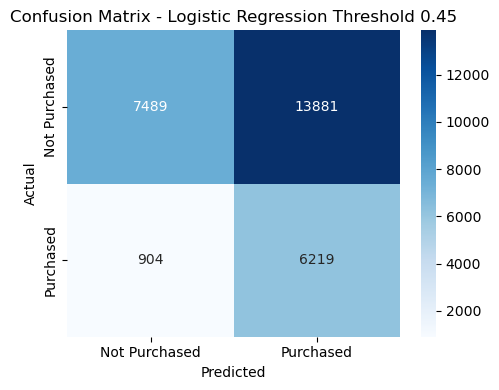

Saved confusion matrix: outputs/confusion_matrices/logistic_regression_threshold_0.45_confusion_matrix.png


In [19]:
log_reg = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    C=0.7,
    solver="lbfgs",
    random_state=RANDOM_STATE
)

log_reg.fit(X_train_scaled, y_train)

y_prob_lr = log_reg.predict_proba(X_test_scaled)[:, 1]

thresholds = np.arange(0.10, 0.90, 0.05)

best_threshold_lr = 0.50
best_score_lr = 0
found_precision_threshold = False

best_f1_threshold_lr = 0.50
best_f1_lr = 0

for threshold in thresholds:
    y_pred_temp = (y_prob_lr >= threshold).astype(int)

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test,
        y_pred_temp,
        average="binary",
        zero_division=0
    )

    # Store best F1 overall as fallback
    if f1 > best_f1_lr:
        best_f1_lr = f1
        best_f1_threshold_lr = threshold

    # Prefer threshold with precision >= 0.40 if possible
    if precision >= 0.40:
        found_precision_threshold = True
        score = f1

        if score > best_score_lr:
            best_score_lr = score
            best_threshold_lr = threshold

    print(
        f"Threshold: {threshold:.2f} | "
        f"Precision: {precision:.3f} | "
        f"Recall: {recall:.3f} | "
        f"F1: {f1:.3f}"
    )

# If no threshold reaches precision >= 0.40, use best F1 threshold
if not found_precision_threshold:
    best_threshold_lr = best_f1_threshold_lr
    best_score_lr = best_f1_lr
    print("\nNo Logistic Regression threshold reached precision >= 0.40.")
    print("Using best F1 threshold instead.")

print("Selected Logistic Regression threshold:", best_threshold_lr)
print("Selected Logistic Regression score:", best_score_lr)

y_pred_lr = (y_prob_lr >= best_threshold_lr).astype(int)

lr_result = evaluate_model(
    f"Logistic Regression Threshold {best_threshold_lr:.2f}",
    y_test,
    y_pred_lr,
    y_prob_lr
)

lr_result["threshold"] = best_threshold_lr

results.append(lr_result)
trained_models["Logistic Regression"] = log_reg

# Random Forest

Threshold: 0.10 | Precision: 0.383 | Recall: 0.991 | F1: 0.552
Threshold: 0.15 | Precision: 0.423 | Recall: 0.984 | F1: 0.592
Threshold: 0.20 | Precision: 0.460 | Recall: 0.970 | F1: 0.624
Threshold: 0.25 | Precision: 0.502 | Recall: 0.950 | F1: 0.657
Threshold: 0.30 | Precision: 0.543 | Recall: 0.921 | F1: 0.683
Threshold: 0.35 | Precision: 0.584 | Recall: 0.886 | F1: 0.704
Threshold: 0.40 | Precision: 0.630 | Recall: 0.844 | F1: 0.721
Threshold: 0.45 | Precision: 0.680 | Recall: 0.797 | F1: 0.734
Threshold: 0.50 | Precision: 0.731 | Recall: 0.749 | F1: 0.740
Threshold: 0.55 | Precision: 0.779 | Recall: 0.697 | F1: 0.736
Threshold: 0.60 | Precision: 0.830 | Recall: 0.640 | F1: 0.722
Threshold: 0.65 | Precision: 0.870 | Recall: 0.579 | F1: 0.695
Threshold: 0.70 | Precision: 0.917 | Recall: 0.524 | F1: 0.667
Threshold: 0.75 | Precision: 0.947 | Recall: 0.466 | F1: 0.625
Threshold: 0.80 | Precision: 0.974 | Recall: 0.403 | F1: 0.570
Threshold: 0.85 | Precision: 0.989 | Recall: 0.289 | F1

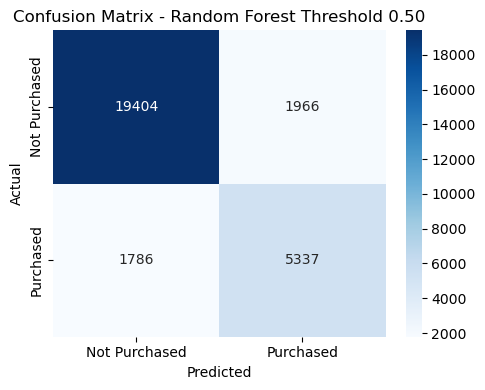

Saved confusion matrix: outputs/confusion_matrices/random_forest_threshold_0.50_confusion_matrix.png


In [20]:
rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=24,
    min_samples_split=6,
    min_samples_leaf=2,
    max_features="sqrt",
    class_weight="balanced_subsample",
    bootstrap=True,
    n_jobs=-1,
    random_state=RANDOM_STATE
)

rf.fit(X_train, y_train)

y_prob_rf = rf.predict_proba(X_test)[:, 1]

thresholds = np.arange(0.10, 0.90, 0.05)

best_threshold_rf = 0.50
best_score_rf = 0
found_precision_threshold = False

best_f1_threshold_rf = 0.50
best_f1_rf = 0

for threshold in thresholds:
    y_pred_temp = (y_prob_rf >= threshold).astype(int)

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test,
        y_pred_temp,
        average="binary",
        zero_division=0
    )

    # Store best F1 overall as fallback
    if f1 > best_f1_rf:
        best_f1_rf = f1
        best_f1_threshold_rf = threshold

    # Prefer a threshold with decent precision
    if precision >= 0.60:
        found_precision_threshold = True
        score = f1

        if score > best_score_rf:
            best_score_rf = score
            best_threshold_rf = threshold

    print(
        f"Threshold: {threshold:.2f} | "
        f"Precision: {precision:.3f} | "
        f"Recall: {recall:.3f} | "
        f"F1: {f1:.3f}"
    )

# If no threshold reaches precision >= 0.60, use best F1 threshold
if not found_precision_threshold:
    best_threshold_rf = best_f1_threshold_rf
    best_score_rf = best_f1_rf
    print("\nNo Random Forest threshold reached precision >= 0.60.")
    print("Using best F1 threshold instead.")

print("Selected Random Forest threshold:", best_threshold_rf)
print("Selected Random Forest score:", best_score_rf)

y_pred_rf = (y_prob_rf >= best_threshold_rf).astype(int)

rf_result = evaluate_model(
    f"Random Forest Threshold {best_threshold_rf:.2f}",
    y_test,
    y_pred_rf,
    y_prob_rf
)

rf_result["threshold"] = best_threshold_rf

results.append(rf_result)

trained_models["Random Forest"] = rf

# XGBoost

Threshold: 0.10 | Precision: 0.472 | Recall: 0.999 | F1: 0.641
Threshold: 0.15 | Precision: 0.499 | Recall: 0.999 | F1: 0.665
Threshold: 0.20 | Precision: 0.522 | Recall: 0.997 | F1: 0.685
Threshold: 0.25 | Precision: 0.542 | Recall: 0.995 | F1: 0.702
Threshold: 0.30 | Precision: 0.564 | Recall: 0.991 | F1: 0.719
Threshold: 0.35 | Precision: 0.587 | Recall: 0.986 | F1: 0.736
Threshold: 0.40 | Precision: 0.614 | Recall: 0.977 | F1: 0.754
Threshold: 0.45 | Precision: 0.646 | Recall: 0.967 | F1: 0.775
Threshold: 0.50 | Precision: 0.683 | Recall: 0.948 | F1: 0.794
Threshold: 0.55 | Precision: 0.720 | Recall: 0.926 | F1: 0.810
Threshold: 0.60 | Precision: 0.760 | Recall: 0.901 | F1: 0.825
Threshold: 0.65 | Precision: 0.797 | Recall: 0.858 | F1: 0.827
Threshold: 0.70 | Precision: 0.834 | Recall: 0.811 | F1: 0.823
Threshold: 0.75 | Precision: 0.873 | Recall: 0.750 | F1: 0.807
Threshold: 0.80 | Precision: 0.913 | Recall: 0.674 | F1: 0.775
Threshold: 0.85 | Precision: 0.947 | Recall: 0.591 | F1

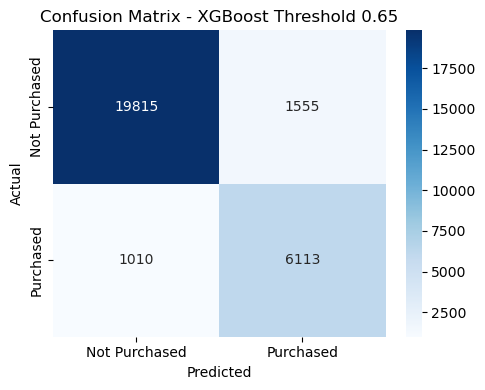

Saved confusion matrix: outputs/confusion_matrices/xgboost_threshold_0.65_confusion_matrix.png


In [21]:
try:
    from xgboost import XGBClassifier

    neg_count = (y_train == 0).sum()
    pos_count = (y_train == 1).sum()

    scale_pos_weight = neg_count / pos_count

    xgb = XGBClassifier(
        n_estimators=800,
        max_depth=4,
        learning_rate=0.025,
        subsample=0.90,
        colsample_bytree=0.90,
        min_child_weight=4,
        gamma=0.2,
        reg_lambda=2.0,
        reg_alpha=0.3,
        scale_pos_weight=scale_pos_weight,
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        n_jobs=-1,
        tree_method="hist"
    )

    xgb.fit(X_train, y_train)

    y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

    thresholds = np.arange(0.10, 0.90, 0.05)

    best_threshold_xgb = 0.50
    best_score_xgb = 0
    found_precision_threshold = False

    best_f1_threshold_xgb = 0.50
    best_f1_xgb = 0

    for threshold in thresholds:
        y_pred_temp = (y_prob_xgb >= threshold).astype(int)

        precision, recall, f1, _ = precision_recall_fscore_support(
            y_test,
            y_pred_temp,
            average="binary",
            zero_division=0
        )

        # Store best F1 overall as fallback
        if f1 > best_f1_xgb:
            best_f1_xgb = f1
            best_f1_threshold_xgb = threshold

        # Prefer a threshold with strong precision
        if precision >= 0.75:
            found_precision_threshold = True
            score = f1

            if score > best_score_xgb:
                best_score_xgb = score
                best_threshold_xgb = threshold

        print(
            f"Threshold: {threshold:.2f} | "
            f"Precision: {precision:.3f} | "
            f"Recall: {recall:.3f} | "
            f"F1: {f1:.3f}"
        )

    # If no threshold reaches precision >= 0.75, use best F1 threshold
    if not found_precision_threshold:
        best_threshold_xgb = best_f1_threshold_xgb
        best_score_xgb = best_f1_xgb
        print("\nNo XGBoost threshold reached precision >= 0.75.")
        print("Using best F1 threshold instead.")

    print("Selected XGBoost threshold:", best_threshold_xgb)
    print("Selected XGBoost score:", best_score_xgb)

    y_pred_xgb = (y_prob_xgb >= best_threshold_xgb).astype(int)

    xgb_result = evaluate_model(
        f"XGBoost Threshold {best_threshold_xgb:.2f}",
        y_test,
        y_pred_xgb,
        y_prob_xgb
    )

    xgb_result["threshold"] = best_threshold_xgb

    results.append(xgb_result)

    trained_models["XGBoost"] = xgb

except Exception as e:
    print("XGBoost failed:")
    print(e)

# ANN GPU setup

In [22]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

torch.manual_seed(RANDOM_STATE)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


X_train_ann = X_train_scaled.astype(np.float32)
X_test_ann = X_test_scaled.astype(np.float32)

y_train_ann = y_train.values.astype(np.float32)
y_test_ann = y_test.values.astype(np.float32)

X_train_tensor = torch.tensor(X_train_ann, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_ann, dtype=torch.float32).view(-1, 1)

X_test_tensor = torch.tensor(X_test_ann, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test_ann, dtype=torch.float32).view(-1, 1)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(
    train_dataset,
    batch_size=512,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=1024,
    shuffle=False
)

input_dim = X_train_ann.shape[1]

print("ANN input dimension:", input_dim)

Device: cuda
GPU: Tesla T4
ANN input dimension: 25


# ANN model

In [23]:
class ANNRecommender(nn.Module):
    def __init__(self, input_dim):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.40),

            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.35),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.25),

            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.15),

            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.net(x)


ann_model = ANNRecommender(input_dim).to(device)

print(ann_model)

ANNRecommender(
  (net): Sequential(
    (0): Linear(in_features=25, out_features=512, bias=True)
    (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.4, inplace=False)
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.35, inplace=False)
    (8): Linear(in_features=256, out_features=128, bias=True)
    (9): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.25, inplace=False)
    (12): Linear(in_features=128, out_features=64, bias=True)
    (13): ReLU()
    (14): Dropout(p=0.15, inplace=False)
    (15): Linear(in_features=64, out_features=1, bias=True)
  )
)


# Train ANN

In [24]:
positive_count = y_train.sum()
negative_count = len(y_train) - positive_count

pos_weight_value = negative_count / positive_count
pos_weight = torch.tensor([pos_weight_value], dtype=torch.float32).to(device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = torch.optim.Adam(
    ann_model.parameters(),
    lr=0.0005,
    weight_decay=1e-4
)

EPOCHS = 150
PATIENCE = 30

train_losses = []

best_loss = float("inf")
best_epoch = 0
patience_counter = 0

best_ann_state = None

for epoch in range(EPOCHS):
    ann_model.train()
    total_loss = 0

    for batch_X, batch_y in train_loader:
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)

        optimizer.zero_grad()

        logits = ann_model(batch_X)
        loss = criterion(logits, batch_y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    train_losses.append(avg_loss)

    print(f"Epoch {epoch+1}/{EPOCHS} - Loss: {avg_loss:.5f}")

    # Early stopping based on training loss
    if avg_loss < best_loss:
        best_loss = avg_loss
        best_epoch = epoch + 1
        patience_counter = 0
        best_ann_state = ann_model.state_dict()
    else:
        patience_counter += 1

    if patience_counter >= PATIENCE:
        print(f"Early stopping triggered at epoch {epoch+1}")
        print(f"Best epoch: {best_epoch} | Best loss: {best_loss:.5f}")
        break

# Load best model state
if best_ann_state is not None:
    ann_model.load_state_dict(best_ann_state)

print("ANN training complete.")
print("Best epoch:", best_epoch)
print("Best loss:", best_loss)

Epoch 1/150 - Loss: 0.70583
Epoch 2/150 - Loss: 0.50182
Epoch 3/150 - Loss: 0.44774
Epoch 4/150 - Loss: 0.41739
Epoch 5/150 - Loss: 0.40102
Epoch 6/150 - Loss: 0.38839
Epoch 7/150 - Loss: 0.37634
Epoch 8/150 - Loss: 0.36216
Epoch 9/150 - Loss: 0.36083
Epoch 10/150 - Loss: 0.35539
Epoch 11/150 - Loss: 0.35869
Epoch 12/150 - Loss: 0.34998
Epoch 13/150 - Loss: 0.34092
Epoch 14/150 - Loss: 0.34119
Epoch 15/150 - Loss: 0.34695
Epoch 16/150 - Loss: 0.33318
Epoch 17/150 - Loss: 0.33093
Epoch 18/150 - Loss: 0.33142
Epoch 19/150 - Loss: 0.32968
Epoch 20/150 - Loss: 0.33133
Epoch 21/150 - Loss: 0.32442
Epoch 22/150 - Loss: 0.32341
Epoch 23/150 - Loss: 0.31914
Epoch 24/150 - Loss: 0.32062
Epoch 25/150 - Loss: 0.32012
Epoch 26/150 - Loss: 0.31597
Epoch 27/150 - Loss: 0.31101
Epoch 28/150 - Loss: 0.31978
Epoch 29/150 - Loss: 0.31615
Epoch 30/150 - Loss: 0.30767
Epoch 31/150 - Loss: 0.30883
Epoch 32/150 - Loss: 0.30705
Epoch 33/150 - Loss: 0.31332
Epoch 34/150 - Loss: 0.30345
Epoch 35/150 - Loss: 0.

# ANN loss curve

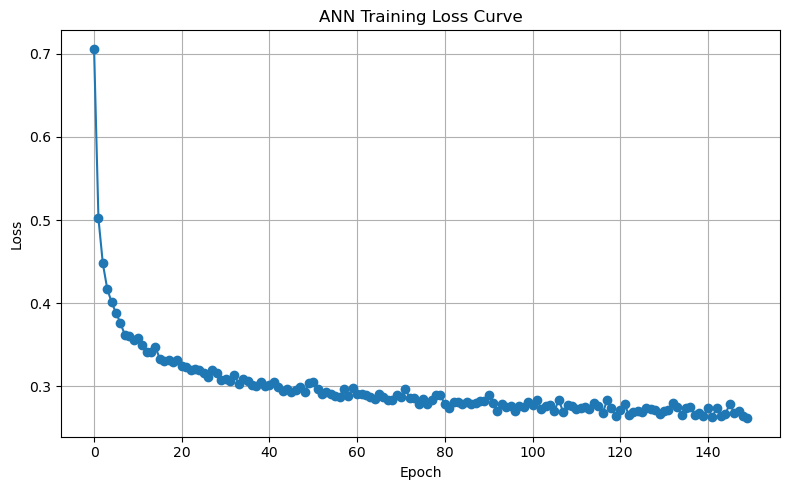

In [25]:
plt.figure(figsize=(8, 5))
plt.plot(train_losses, marker="o")
plt.title("ANN Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.tight_layout()
plt.show()

# Evaluate ANN

In [26]:
ann_model.eval()

all_probs = []

with torch.no_grad():
    for batch_X, _ in test_loader:
        batch_X = batch_X.to(device)

        logits = ann_model(batch_X)
        probs = torch.sigmoid(logits)

        all_probs.extend(probs.cpu().numpy().flatten())

y_prob_ann = np.array(all_probs)

print("ANN probability range:")
print("min:", y_prob_ann.min())
print("max:", y_prob_ann.max())
print("mean:", y_prob_ann.mean())

ANN probability range:
min: 1.3975277e-31
max: 0.99977833
mean: 0.31334618


In [27]:
thresholds = np.arange(0.10, 0.90, 0.05)

best_threshold = 0.50
best_f1 = 0

threshold_results = []

for threshold in thresholds:
    y_pred_temp = (y_prob_ann >= threshold).astype(int)

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test,
        y_pred_temp,
        average="binary",
        zero_division=0
    )

    threshold_results.append({
        "threshold": threshold,
        "precision": precision,
        "recall": recall,
        "f1": f1
    })

    print(
        f"Threshold: {threshold:.2f} | "
        f"Precision: {precision:.3f} | "
        f"Recall: {recall:.3f} | "
        f"F1: {f1:.3f}"
    )

    if f1 > best_f1:
        best_f1 = f1
        best_threshold = threshold

print("\nBest ANN threshold:", best_threshold)
print("Best ANN F1:", best_f1)

threshold_df = pd.DataFrame(threshold_results)
threshold_df.to_csv(OUTPUT_DIR / "ann_threshold_tuning.csv", index=False)

display(threshold_df)

Threshold: 0.10 | Precision: 0.604 | Recall: 1.000 | F1: 0.753
Threshold: 0.15 | Precision: 0.620 | Recall: 0.999 | F1: 0.765
Threshold: 0.20 | Precision: 0.638 | Recall: 0.997 | F1: 0.778
Threshold: 0.25 | Precision: 0.652 | Recall: 0.994 | F1: 0.788
Threshold: 0.30 | Precision: 0.667 | Recall: 0.991 | F1: 0.797
Threshold: 0.35 | Precision: 0.680 | Recall: 0.988 | F1: 0.805
Threshold: 0.40 | Precision: 0.693 | Recall: 0.984 | F1: 0.814
Threshold: 0.45 | Precision: 0.711 | Recall: 0.976 | F1: 0.823
Threshold: 0.50 | Precision: 0.732 | Recall: 0.967 | F1: 0.833
Threshold: 0.55 | Precision: 0.758 | Recall: 0.952 | F1: 0.844
Threshold: 0.60 | Precision: 0.784 | Recall: 0.937 | F1: 0.854
Threshold: 0.65 | Precision: 0.813 | Recall: 0.914 | F1: 0.860
Threshold: 0.70 | Precision: 0.844 | Recall: 0.888 | F1: 0.865
Threshold: 0.75 | Precision: 0.872 | Recall: 0.855 | F1: 0.864
Threshold: 0.80 | Precision: 0.899 | Recall: 0.820 | F1: 0.858
Threshold: 0.85 | Precision: 0.923 | Recall: 0.774 | F1

,threshold,precision,recall,f1
0,0.10,0.603559,0.999860,0.752735
1,0.15,0.620064,0.998736,0.765111
2,0.20,0.637637,0.997052,0.777833
3,0.25,0.652086,0.994104,0.787565
4,0.30,0.666604,0.991155,0.797110
5,0.35,0.679741,0.987786,0.805311
6,0.40,0.693472,0.984276,0.813671
7,0.45,0.710680,0.976274,0.822569
8,0.50,0.732426,0.966868,0.833475
9,0.55,0.757935,0.952127,0.844005


ANN GPU Threshold 0.70
               precision    recall  f1-score   support

Not Purchased       0.96      0.95      0.95     21370
    Purchased       0.84      0.89      0.87      7123

     accuracy                           0.93     28493
    macro avg       0.90      0.92      0.91     28493
 weighted avg       0.93      0.93      0.93     28493



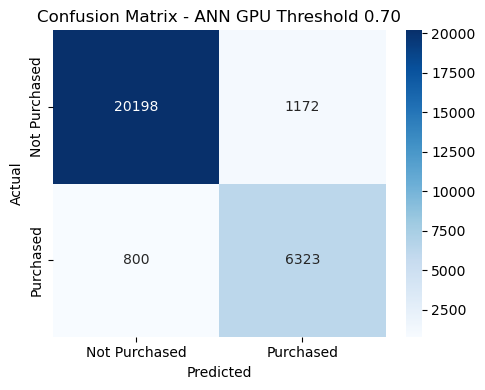

Saved confusion matrix: outputs/confusion_matrices/ann_gpu_threshold_0.70_confusion_matrix.png


In [28]:
y_pred_ann = (y_prob_ann >= best_threshold).astype(int)

ann_result = evaluate_model(
    f"ANN GPU Threshold {best_threshold:.2f}",
    y_test,
    y_pred_ann,
    y_prob_ann
)

ann_result["threshold"] = best_threshold

results.append(ann_result)

trained_models["ANN GPU"] = ann_model

# Recommendation metric helpers

In [29]:
def model_scores(model_name, model, X_score):
    if model_name == "ANN GPU":
        X_scaled = scaler.transform(X_score)
        X_tensor = torch.tensor(
            X_scaled.astype(np.float32),
            dtype=torch.float32
        ).to(device)

        model.eval()

        with torch.no_grad():
            logits = model(X_tensor)
            probs = torch.sigmoid(logits).cpu().numpy().flatten()

        return probs

    elif model_name == "Logistic Regression":
        X_scaled = scaler.transform(X_score)
        return model.predict_proba(X_scaled)[:, 1]

    else:
        return model.predict_proba(X_score)[:, 1]

# Calculate Precision@K and Recall@K

In [30]:
def precision_recall_at_k(model_name, model, k=5, max_eval_clients=300):
    """
    Evaluation version.
    IMPORTANT:
    Do NOT remove already bought items here because actual_items are purchased SKUs.
    """

    actual_by_client = (
        test_pairs[test_pairs["label"] == 1]
        .groupby("client_id")["sku"]
        .apply(set)
        .to_dict()
    )

    eval_clients = list(actual_by_client.keys())[:max_eval_clients]

    precisions = []
    recalls = []

    for client in eval_clients:
        actual_items = actual_by_client.get(client, set())

        if len(actual_items) == 0:
            continue

        if client not in user_features.index:
            continue

        user_row = user_features.loc[[client]].reset_index()

        # Candidate products include popular products + actual test positives
        candidate_skus = list(set(popular_skus[:TOP_POPULAR_PRODUCTS]).union(actual_items))

        candidate_df = pd.DataFrame({"sku": candidate_skus})

        user_block = pd.concat([user_row] * len(candidate_df), ignore_index=True)
        candidate_df = candidate_df.reset_index(drop=True)

        score_df = pd.concat([user_block, candidate_df], axis=1)

        score_df = score_df.merge(
            product_features.reset_index(),
            on="sku",
            how="left"
        )

        score_df = score_df.fillna(0)

        if score_df.empty:
            continue

        X_score = score_df.drop(columns=["client_id", "sku"], errors="ignore")
        X_score = X_score.select_dtypes(include=[np.number])
        X_score = X_score.reindex(columns=X.columns, fill_value=0)

        scores = model_scores(model_name, model, X_score)

        score_df["score"] = scores

        top_k_items = (
            score_df.sort_values("score", ascending=False)
            .head(k)["sku"]
            .tolist()
        )

        hits = len(set(top_k_items).intersection(actual_items))

        precisions.append(hits / k)
        recalls.append(hits / len(actual_items))

    if len(precisions) == 0:
        return 0.0, 0.0

    return float(np.mean(precisions)), float(np.mean(recalls))

# Popularity baseline

In [31]:
results_dict = {r["model"]: r for r in results}

ann_result_name = [r["model"] for r in results if r["model"].startswith("ANN GPU")][0]

model_eval_map = {
    "Logistic Regression": trained_models["Logistic Regression"],
    "Random Forest": trained_models["Random Forest"]
}

if "XGBoost" in trained_models:
    model_eval_map["XGBoost"] = trained_models["XGBoost"]

model_eval_map["ANN GPU"] = trained_models["ANN GPU"]

for model_name, model in model_eval_map.items():
    print("\nRecommendation metrics:", model_name)

    p5, r5 = precision_recall_at_k(model_name, model, k=5)
    p10, r10 = precision_recall_at_k(model_name, model, k=10)

    if model_name == "ANN GPU":
        target_result_name = ann_result_name
    else:
        # Handles names like "XGBoost Threshold 0.45"
        possible_names = [r["model"] for r in results if r["model"].startswith(model_name)]
        target_result_name = possible_names[0] if possible_names else model_name

    results_dict[target_result_name]["precision_at_5"] = p5
    results_dict[target_result_name]["recall_at_5"] = r5
    results_dict[target_result_name]["precision_at_10"] = p10
    results_dict[target_result_name]["recall_at_10"] = r10

    print("Precision@5:", p5)
    print("Recall@5:", r5)
    print("Precision@10:", p10)
    print("Recall@10:", r10)


Recommendation metrics: Logistic Regression
Precision@5: 0.004000000000000001
Recall@5: 0.007261904761904761
Precision@10: 0.0023333333333333335
Recall@10: 0.008373015873015872

Recommendation metrics: Random Forest
Precision@5: 0.13733333333333334
Recall@5: 0.6222619047619048
Precision@10: 0.07633333333333332
Recall@10: 0.6648809523809525

Recommendation metrics: XGBoost
Precision@5: 0.1513333333333333
Recall@5: 0.6713412698412698
Precision@10: 0.08199999999999998
Recall@10: 0.717452380952381

Recommendation metrics: ANN GPU
Precision@5: 0.17066666666666666
Recall@5: 0.7677063492063493
Precision@10: 0.093
Recall@10: 0.8250396825396825


In [32]:
actual_by_client = (
    test_pairs[test_pairs["label"] == 1]
    .groupby("client_id")["sku"]
    .apply(set)
    .to_dict()
)

def popularity_precision_recall(k):
    top_k = set(popular_skus[:k])

    precisions = []
    recalls = []

    for client, actual_items in actual_by_client.items():
        hits = len(top_k.intersection(actual_items))

        precisions.append(hits / k)
        recalls.append(hits / len(actual_items))

    if len(precisions) == 0:
        return 0.0, 0.0

    return float(np.mean(precisions)), float(np.mean(recalls))


pop_p5, pop_r5 = popularity_precision_recall(5)
pop_p10, pop_r10 = popularity_precision_recall(10)

results_dict["Popularity Baseline"] = {
    "model": "Popularity Baseline",
    "accuracy": np.nan,
    "precision": np.nan,
    "recall": np.nan,
    "f1_score": np.nan,
    "auroc": np.nan,
    "precision_at_5": pop_p5,
    "recall_at_5": pop_r5,
    "precision_at_10": pop_p10,
    "recall_at_10": pop_r10,
    "threshold": np.nan
}

print(results_dict["Popularity Baseline"])

{'model': 'Popularity Baseline', 'accuracy': nan, 'precision': nan, 'recall': nan, 'f1_score': nan, 'auroc': nan, 'precision_at_5': 0.000832387438516837, 'recall_at_5': 0.0032791020305208726, 'precision_at_10': 0.0007377979568671965, 'recall_at_10': 0.005990667171143902, 'threshold': nan}


# Final metrics table

In [33]:
metrics_df = pd.DataFrame(results_dict.values())

metrics_df["selection_score"] = (
    0.25 * metrics_df["precision_at_5"].fillna(0)
    + 0.25 * metrics_df["recall_at_5"].fillna(0)
    + 0.15 * metrics_df["precision_at_10"].fillna(0)
    + 0.15 * metrics_df["recall_at_10"].fillna(0)
    + 0.10 * metrics_df["f1_score"].fillna(0)
    + 0.10 * metrics_df["auroc"].fillna(0)
)

metrics_df = metrics_df.sort_values("selection_score", ascending=False)

metrics_df.to_csv(OUTPUT_DIR / "metrics.csv", index=False)

display(metrics_df)

,model,accuracy,precision,recall,f1_score,auroc,threshold,precision_at_5,recall_at_5,precision_at_10,recall_at_10,selection_score
3,ANN GPU Threshold 0.70,0.930790,0.843629,0.887688,0.865098,0.982251,0.70,0.170667,0.767706,0.093000,0.825040,0.557034
2,XGBoost Threshold 0.65,0.909978,0.797209,0.858206,0.826584,0.969714,0.65,0.151333,0.671341,0.082000,0.717452,0.505216
1,Random Forest Threshold 0.50,0.868319,0.730796,0.749263,0.739914,0.930095,0.50,0.137333,0.622262,0.076333,0.664881,0.468082
0,Logistic Regression Threshold 0.45,0.481101,0.309403,0.873087,0.456893,0.586972,0.45,0.004000,0.007262,0.002333,0.008373,0.108808
4,Popularity Baseline,NaN,NaN,NaN,NaN,NaN,NaN,0.000832,0.003279,0.000738,0.005991,0.002037


# Model comparison chart

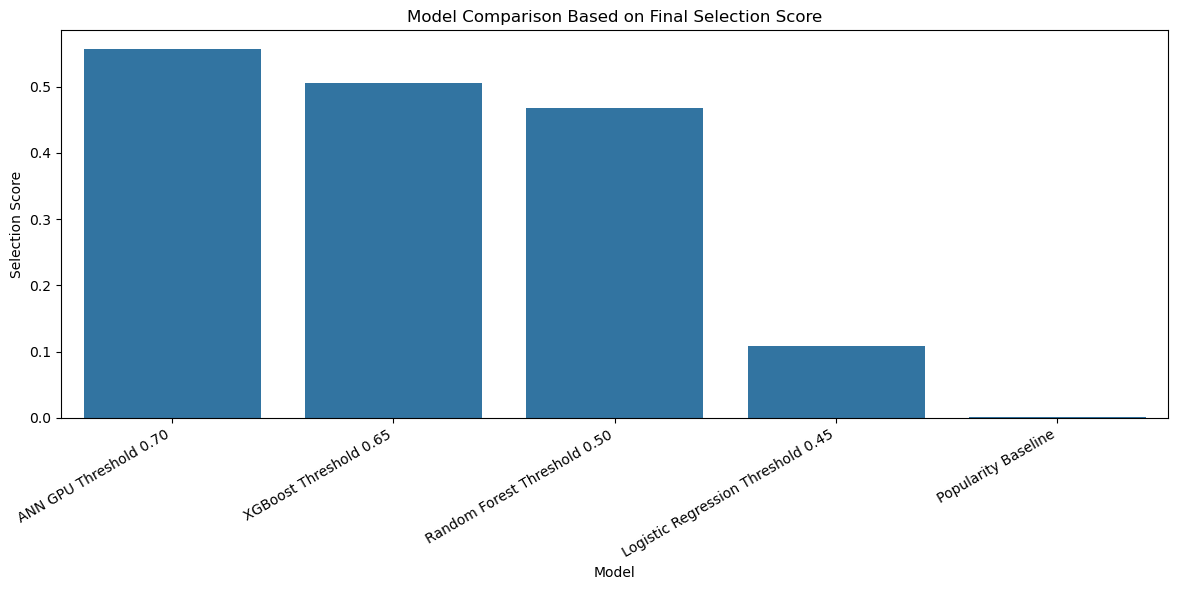

In [34]:
plt.figure(figsize=(12, 6))
sns.barplot(data=metrics_df, x="model", y="selection_score")
plt.title("Model Comparison Based on Final Selection Score")
plt.xlabel("Model")
plt.ylabel("Selection Score")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

# Save best model

In [35]:
best_model_name = metrics_df.iloc[0]["model"]

if best_model_name == "Popularity Baseline":
    best_model_name = metrics_df[metrics_df["model"] != "Popularity Baseline"].iloc[0]["model"]

print("Best model selected:", best_model_name)

# Map selected name to actual model object
if best_model_name.startswith("ANN GPU"):
    actual_model_key = "ANN GPU"
else:
    actual_model_key = best_model_name

best_model = trained_models[actual_model_key]

bundle = {
    "best_model_name": best_model_name,
    "actual_model_key": actual_model_key,
    "scaler": scaler,
    "x_columns": X.columns.tolist(),
    "user_features": user_features,
    "product_features": product_features,
    "popular_skus": popular_skus,
    "metrics": metrics_df,
    "ann_threshold": best_threshold,
    "is_ann": actual_model_key == "ANN GPU",
    "input_dim": input_dim
}

if actual_model_key == "ANN GPU":
    torch.save(best_model.state_dict(), MODEL_DIR / "best_ann_gpu.pt")
else:
    joblib.dump(best_model, MODEL_DIR / "best_model.joblib")

joblib.dump(bundle, MODEL_DIR / "recommender_bundle.joblib")

print("Saved model files.")
print("Bundle:", MODEL_DIR / "recommender_bundle.joblib")

Best model selected: ANN GPU Threshold 0.70
Saved model files.
Bundle: models/recommender_bundle.joblib


# Recommendation function

In [36]:
def recommend_for_client(client_id, model_name, model, top_n=10):
    if client_id not in user_features.index:
        return pd.DataFrame()

    user_row = user_features.loc[[client_id]].reset_index()
    candidate_df = pd.DataFrame({"sku": popular_skus[:TOP_POPULAR_PRODUCTS]})

    user_block = pd.concat([user_row] * len(candidate_df), ignore_index=True)
    candidate_df = candidate_df.reset_index(drop=True)

    score_df = pd.concat([user_block, candidate_df], axis=1)

    score_df = score_df.merge(
        product_features.reset_index(),
        on="sku",
        how="left"
    )

    score_df = score_df.fillna(0)

    already_bought = set(buys[buys["client_id"] == client_id]["sku"].unique())
    score_df = score_df[~score_df["sku"].isin(already_bought)]

    if score_df.empty:
        return pd.DataFrame()

    X_score = score_df.drop(columns=["client_id", "sku"], errors="ignore")
    X_score = X_score.select_dtypes(include=[np.number])
    X_score = X_score.reindex(columns=X.columns, fill_value=0)

    scores = model_scores(model_name, model, X_score)

    score_df["score"] = scores

    recs = score_df.sort_values("score", ascending=False).head(top_n).copy()

    recs["rank"] = range(1, len(recs) + 1)

    def reason(row):
        reasons = []

        if "engagement_score" in user_features.columns:
            reasons.append("user has strong behavioural engagement")

        if "cart_add_count" in user_features.columns and user_features.loc[client_id, "cart_add_count"] > 0:
            reasons.append("cart activity indicates product interest")

        if "page_visit_count" in user_features.columns and user_features.loc[client_id, "page_visit_count"] > 0:
            reasons.append("browsing history supports recommendation")

        if len(reasons) == 0:
            reasons.append("high predicted purchase probability")

        return "; ".join(reasons)

    recs["reason"] = recs.apply(reason, axis=1)

    keep_cols = ["client_id", "rank", "sku", "score", "reason"]

    for col in product_features.columns:
        if col in recs.columns:
            keep_cols.append(col)

    return recs[keep_cols]

# Test recommendation

In [37]:
demo_client = list(user_features.index)[0]

print("Demo client:", demo_client)

recommend_for_client(
    demo_client,
    actual_model_key,
    best_model,
    top_n=10
)

Demo client: 8880128


,client_id,rank,sku,score,reason,category,price
154,8880128,1,1459508,0.988225,user has strong behavioural engagement; cart a...,835,58
663,8880128,2,810968,0.988225,user has strong behavioural engagement; cart a...,835,58
626,8880128,3,1300498,0.985893,user has strong behavioural engagement; cart a...,4740,58
598,8880128,4,376353,0.984450,user has strong behavioural engagement; cart a...,835,59
46,8880128,5,640169,0.982057,user has strong behavioural engagement; cart a...,791,78
549,8880128,6,195683,0.980669,user has strong behavioural engagement; cart a...,835,76
711,8880128,7,664641,0.976903,user has strong behavioural engagement; cart a...,4683,59
554,8880128,8,1545687,0.975648,user has strong behavioural engagement; cart a...,4814,79
337,8880128,9,166121,0.972414,user has strong behavioural engagement; cart a...,4826,76
70,8880128,10,1339705,0.963763,user has strong behavioural engagement; cart a...,4657,79


In [38]:
%%writefile streamlit_app.py

import streamlit as st
import pandas as pd
from pathlib import Path
import plotly.express as px
import os

# ============================================================
# Page Configuration
# ============================================================

st.set_page_config(
    page_title="AI Product Recommendation Studio",
    page_icon="🛒",
    layout="wide"
)

# ============================================================
# Custom Styling
# ============================================================

st.markdown(
    """
    <style>
    .stApp {
        background: linear-gradient(135deg, #020617 0%, #0f172a 45%, #111827 100%);
        color: #f8fafc;
    }

    .main-title {
        font-size: 44px;
        font-weight: 800;
        background: linear-gradient(90deg, #38bdf8, #a78bfa, #f472b6);
        -webkit-background-clip: text;
        -webkit-text-fill-color: transparent;
        margin-bottom: 5px;
    }

    .subtitle {
        color: #cbd5e1;
        font-size: 18px;
        margin-bottom: 25px;
    }

    .card {
        background: rgba(255, 255, 255, 0.08);
        padding: 22px;
        border-radius: 18px;
        border: 1px solid rgba(255,255,255,0.16);
        box-shadow: 0 8px 30px rgba(0,0,0,0.25);
        margin-bottom: 18px;
    }

    .rec-card {
        background: linear-gradient(135deg, rgba(30,41,59,0.96), rgba(15,23,42,0.96));
        border-left: 6px solid #38bdf8;
        padding: 18px;
        border-radius: 16px;
        margin-bottom: 14px;
        box-shadow: 0 8px 24px rgba(0,0,0,0.25);
    }

    .rank {
        display: inline-block;
        background: linear-gradient(135deg, #38bdf8, #a78bfa);
        color: #020617;
        padding: 6px 12px;
        border-radius: 999px;
        font-weight: 800;
        margin-right: 10px;
    }

    .sku {
        font-size: 24px;
        font-weight: 750;
        color: #f8fafc;
    }

    .reason {
        color: #cbd5e1;
        margin-top: 8px;
        font-size: 15px;
    }

    .score {
        display: inline-block;
        color: #86efac;
        background: rgba(34,197,94,0.15);
        padding: 5px 12px;
        border-radius: 999px;
        margin-top: 10px;
        font-weight: 700;
    }

    section[data-testid="stSidebar"] {
        background: #020617;
    }

    .small-note {
        color: #94a3b8;
        font-size: 14px;
    }
    </style>
    """,
    unsafe_allow_html=True
)

# ============================================================
# File Paths
# ============================================================

OUTPUT_DIR = Path("outputs")
CM_DIR = OUTPUT_DIR / "confusion_matrices"

METRICS_PATH = OUTPUT_DIR / "metrics.csv"
RECS_PATH = OUTPUT_DIR / "demo_recommendations.csv"
PROFILES_PATH = OUTPUT_DIR / "user_profiles.csv"

# ============================================================
# Load Data
# ============================================================

@st.cache_data
def load_data():
    metrics = pd.read_csv(METRICS_PATH)
    recs = pd.read_csv(RECS_PATH)
    profiles = pd.read_csv(PROFILES_PATH)
    return metrics, recs, profiles


try:
    metrics_df, recs_df, profiles_df = load_data()
except Exception as e:
    st.error(
        "Required files are missing. Make sure these files exist: "
        "outputs/metrics.csv, outputs/demo_recommendations.csv, outputs/user_profiles.csv"
    )
    st.exception(e)
    st.stop()

# ============================================================
# Header
# ============================================================

st.markdown('<div class="main-title">AI Product Recommendation Studio</div>', unsafe_allow_html=True)
st.markdown(
    '<div class="subtitle">Interactive Top-N product recommendation dashboard using Synerise behavioural data</div>',
    unsafe_allow_html=True
)

# ============================================================
# Sidebar
# ============================================================

st.sidebar.header("Control Panel")

client_ids = recs_df["client_id"].unique().tolist()

selected_client = st.sidebar.selectbox(
    "Select Client ID",
    client_ids
)

top_n = st.sidebar.slider(
    "Number of Recommendations",
    min_value=3,
    max_value=10,
    value=5
)

page = st.sidebar.radio(
    "Navigate",
    [
        "Recommendation Demo",
        "Client Behaviour Profile",
        "Model Performance",
        "Confusion Matrices",
        "About System"
    ]
)

# Best model
if "selection_score" in metrics_df.columns:
    best_model_row = metrics_df.sort_values("selection_score", ascending=False).iloc[0]
else:
    best_model_row = metrics_df.iloc[0]

best_model = best_model_row["model"]

st.sidebar.markdown("---")
st.sidebar.write("Selected final model:")
st.sidebar.success(str(best_model))

# ============================================================
# Page 1 — Recommendation Demo
# ============================================================

if page == "Recommendation Demo":

    client_recs = (
        recs_df[recs_df["client_id"] == selected_client]
        .sort_values("rank")
        .head(top_n)
    )

    st.markdown('<div class="card">', unsafe_allow_html=True)
    st.subheader("Recommendation Overview")

    col1, col2, col3, col4 = st.columns(4)

    col1.metric("Client ID", str(selected_client))
    col2.metric("Top-N", str(top_n))
    col3.metric("Recommendations", str(len(client_recs)))
    col4.metric("Best Model", str(best_model))

    st.markdown(
        '<div class="small-note">Products are shown as anonymised SKU identifiers because the Synerise dataset does not provide real public product names/images.</div>',
        unsafe_allow_html=True
    )

    st.markdown("</div>", unsafe_allow_html=True)

    st.subheader("Top Product Recommendations")

    if client_recs.empty:
        st.warning("No recommendations available for this client.")
    else:
        for _, row in client_recs.iterrows():
            score = row.get("score", 0)
            reason = row.get("reason", "High predicted purchase probability")

            st.markdown(
                f"""
                <div class="rec-card">
                    <span class="rank">#{int(row['rank'])}</span>
                    <span class="sku">SKU: {row['sku']}</span>
                    <div class="score">Prediction Score: {float(score):.4f}</div>
                    <div class="reason">Reason: {reason}</div>
                </div>
                """,
                unsafe_allow_html=True
            )

    st.markdown('<div class="card">', unsafe_allow_html=True)
    st.subheader("Recommendation Score Chart")

    if not client_recs.empty and "score" in client_recs.columns:
        fig = px.bar(
            client_recs,
            x="sku",
            y="score",
            title="Top-N Product Recommendation Scores",
            labels={
                "sku": "Recommended SKU",
                "score": "Prediction Score"
            }
        )
        st.plotly_chart(fig, use_container_width=True)
    else:
        st.info("No score column available.")

    st.markdown("</div>", unsafe_allow_html=True)

    st.markdown('<div class="card">', unsafe_allow_html=True)
    st.subheader("Recommendation Table")
    st.dataframe(client_recs, use_container_width=True)
    st.markdown("</div>", unsafe_allow_html=True)

# ============================================================
# Page 2 — Client Behaviour Profile
# ============================================================

elif page == "Client Behaviour Profile":

    st.markdown('<div class="card">', unsafe_allow_html=True)
    st.subheader("Client Behaviour Summary")

    profile = profiles_df[profiles_df["client_id"] == selected_client]

    if profile.empty:
        st.warning("No profile available for this client.")
    else:
        profile_row = profile.iloc[0]

        metric_cols = [
            col for col in [
                "buy_count",
                "unique_skus_bought",
                "cart_add_count",
                "cart_remove_count",
                "page_visit_count",
                "search_count",
                "engagement_score",
                "exploration_score"
            ]
            if col in profile.columns
        ]

        cols = st.columns(4)

        for i, col in enumerate(metric_cols):
            value = profile_row[col]
            try:
                value = round(float(value), 2)
            except Exception:
                pass

            cols[i % 4].metric(col.replace("_", " ").title(), value)

        st.markdown("</div>", unsafe_allow_html=True)

        st.markdown('<div class="card">', unsafe_allow_html=True)
        st.subheader("Full Client Feature Vector")
        profile_display = profile.T.reset_index()
        profile_display.columns = ["Feature", "Value"]
        st.dataframe(profile_display, use_container_width=True)
        st.markdown("</div>", unsafe_allow_html=True)

        numeric_profile = profile.drop(columns=["client_id"], errors="ignore")
        numeric_profile = numeric_profile.select_dtypes(include="number")

        if not numeric_profile.empty:
            st.markdown('<div class="card">', unsafe_allow_html=True)
            st.subheader("Behaviour Feature Chart")

            chart_df = numeric_profile.T.reset_index()
            chart_df.columns = ["Feature", "Value"]

            fig = px.bar(
                chart_df.head(20),
                x="Feature",
                y="Value",
                title="Client Behaviour Feature Values"
            )
            fig.update_layout(xaxis_tickangle=-35)

            st.plotly_chart(fig, use_container_width=True)
            st.markdown("</div>", unsafe_allow_html=True)

# ============================================================
# Page 3 — Model Performance
# ============================================================

elif page == "Model Performance":

    st.markdown('<div class="card">', unsafe_allow_html=True)
    st.subheader("Model Comparison Table")

    st.dataframe(metrics_df, use_container_width=True)

    st.markdown("</div>", unsafe_allow_html=True)

    metric_options = [
        col for col in [
            "accuracy",
            "precision",
            "recall",
            "f1_score",
            "auroc",
            "precision_at_5",
            "recall_at_5",
            "precision_at_10",
            "recall_at_10",
            "selection_score"
        ]
        if col in metrics_df.columns
    ]

    if metric_options:
        selected_metric = st.selectbox(
            "Choose metric for model comparison chart",
            metric_options,
            index=metric_options.index("selection_score") if "selection_score" in metric_options else 0
        )

        chart_df = metrics_df.copy()
        chart_df[selected_metric] = pd.to_numeric(chart_df[selected_metric], errors="coerce")

        fig = px.bar(
            chart_df.sort_values(selected_metric, ascending=False),
            x="model",
            y=selected_metric,
            title=f"Model Comparison by {selected_metric}",
            labels={
                "model": "Model",
                selected_metric: selected_metric
            }
        )

        st.plotly_chart(fig, use_container_width=True)

    st.markdown('<div class="card">', unsafe_allow_html=True)
    st.subheader("Final Model Interpretation")

    st.write(
        """
        The model selection is based on both classification metrics and Top-N recommendation metrics.
        For a recommender system, Precision@K and Recall@K are more important than accuracy alone,
        because the system needs to rank relevant products near the top of the recommendation list.
        """
    )

    st.write(f"Final selected model: **{best_model}**")

    st.markdown("</div>", unsafe_allow_html=True)

# ============================================================
# Page 4 — Confusion Matrices
# ============================================================

elif page == "Confusion Matrices":

    st.markdown('<div class="card">', unsafe_allow_html=True)
    st.subheader("Saved Confusion Matrices")

    if not CM_DIR.exists():
        st.warning("No confusion_matrices folder found.")
        st.stop()

    cm_files = sorted([
        file for file in CM_DIR.iterdir()
        if file.suffix.lower() in [".png", ".jpg", ".jpeg"]
    ])

    if len(cm_files) == 0:
        st.warning("No confusion matrix image files found.")
    else:
        selected_cm = st.selectbox(
            "Select confusion matrix",
            cm_files,
            format_func=lambda x: x.name
        )

        st.image(str(selected_cm), caption=selected_cm.name, use_container_width=True)

    st.markdown("</div>", unsafe_allow_html=True)

    st.markdown('<div class="card">', unsafe_allow_html=True)
    st.subheader("Confusion Matrix Meaning")

    st.write(
        """
        In this project, the confusion matrix evaluates the binary product-purchase prediction task.
        A true positive means the model correctly predicted that a client would purchase a product.
        A false positive means the model predicted purchase, but the product was not actually purchased.
        A false negative means the model missed a product that the client actually purchased.
        """
    )

    st.markdown("</div>", unsafe_allow_html=True)

# ============================================================
# Page 5 — About System
# ============================================================

elif page == "About System":

    st.markdown('<div class="card">', unsafe_allow_html=True)

    st.subheader("About This Recommendation System")

    st.write(
        """
        This dashboard demonstrates an AI-based product recommendation system using the Synerise RecSys dataset.
        The recommendation task is formulated as a client-product ranking problem. Each training sample represents
        a client-product pair, where the target label indicates whether the client purchased that product.
        """
    )

    st.write(
        """
        The system uses behavioural features from purchase activity, cart activity, page visits, search behaviour,
        and product metadata. Multiple models were trained and compared, including Logistic Regression, Random Forest,
        XGBoost and a GPU-based ANN.
        """
    )

    st.write(
        """
        Since the dataset is anonymised, product outputs are displayed as SKU identifiers rather than real product names
        or product images.
        """
    )

    st.markdown("</div>", unsafe_allow_html=True)

    st.markdown('<div class="card">', unsafe_allow_html=True)

    st.subheader("Pipeline Summary")

    st.write(
        """
        1. Load Synerise event data in SageMaker  
        2. Process large event files using batch-based feature engineering  
        3. Build client behaviour profiles  
        4. Create client-product training pairs  
        5. Train and compare multiple models  
        6. Evaluate using confusion matrices and Top-N recommendation metrics  
        7. Save recommendations for Streamlit demonstration  
        """
    )

    st.markdown("</div>", unsafe_allow_html=True)

Writing streamlit_app.py


In [39]:
%%writefile requirements.txt
streamlit
pandas
numpy
plotly
scikit-learn
joblib
xgboost
torch

Writing requirements.txt


In [40]:
%%writefile README_RUN_APP.txt
AI Product Recommendation Studio - Streamlit Demo

How to run:

1. Open terminal inside this folder.

2. Install dependencies:

   pip install -r requirements.txt

3. Run Streamlit:

   streamlit run streamlit_app.py

Required files:
- streamlit_app.py
- outputs/metrics.csv
- outputs/demo_recommendations.csv
- outputs/user_profiles.csv
- outputs/confusion_matrices/

Important:
This demo uses pre-generated recommendation outputs.
It does not load the full Synerise dataset.

Writing README_RUN_APP.txt


In [42]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

user_features.reset_index().to_csv(OUTPUT_DIR / "user_profiles.csv", index=False)

print("Saved:", OUTPUT_DIR / "user_profiles.csv")

Saved: outputs/user_profiles.csv


In [43]:
def recommend_for_client(client_id, model_name, model, top_n=10):
    if client_id not in user_features.index:
        return pd.DataFrame()

    user_row = user_features.loc[[client_id]].reset_index()
    candidate_df = pd.DataFrame({"sku": popular_skus[:TOP_POPULAR_PRODUCTS]})

    user_block = pd.concat([user_row] * len(candidate_df), ignore_index=True)
    candidate_df = candidate_df.reset_index(drop=True)

    score_df = pd.concat([user_block, candidate_df], axis=1)

    score_df = score_df.merge(
        product_features.reset_index(),
        on="sku",
        how="left"
    )

    score_df = score_df.fillna(0)

    already_bought = set(buys[buys["client_id"] == client_id]["sku"].unique())
    score_df = score_df[~score_df["sku"].isin(already_bought)]

    if score_df.empty:
        return pd.DataFrame()

    X_score = score_df.drop(columns=["client_id", "sku"], errors="ignore")
    X_score = X_score.select_dtypes(include=[np.number])
    X_score = X_score.reindex(columns=X.columns, fill_value=0)

    scores = model_scores(model_name, model, X_score)

    score_df["score"] = scores

    recs = score_df.sort_values("score", ascending=False).head(top_n).copy()
    recs["rank"] = range(1, len(recs) + 1)

    recs["reason"] = (
        "Recommended based on purchase, cart, browsing, search behaviour and product metadata"
    )

    return recs[["client_id", "rank", "sku", "score", "reason"]]

In [44]:
best_model_name = metrics_df.sort_values("selection_score", ascending=False).iloc[0]["model"]

if best_model_name.startswith("ANN GPU"):
    actual_model_key = "ANN GPU"
elif best_model_name.startswith("XGBoost"):
    actual_model_key = "XGBoost"
elif best_model_name.startswith("Random Forest"):
    actual_model_key = "Random Forest"
elif best_model_name.startswith("Logistic Regression"):
    actual_model_key = "Logistic Regression"
else:
    actual_model_key = list(trained_models.keys())[0]

best_model = trained_models[actual_model_key]

print("Using model:", actual_model_key)

demo_clients = list(user_features.index[:200])

all_recs = []

for client in demo_clients:
    recs = recommend_for_client(
        client,
        actual_model_key,
        best_model,
        top_n=10
    )

    if not recs.empty:
        all_recs.append(recs)

if len(all_recs) > 0:
    demo_recs_df = pd.concat(all_recs, ignore_index=True)
    demo_recs_df.to_csv(OUTPUT_DIR / "demo_recommendations.csv", index=False)

    print("Saved:", OUTPUT_DIR / "demo_recommendations.csv")
    display(demo_recs_df.head())
else:
    print("No recommendations generated.")

Using model: ANN GPU
Saved: outputs/demo_recommendations.csv


,client_id,rank,sku,score,reason
0,8880128,1,1459508,0.988225,"Recommended based on purchase, cart, browsing,..."
1,8880128,2,810968,0.988225,"Recommended based on purchase, cart, browsing,..."
2,8880128,3,1300498,0.985893,"Recommended based on purchase, cart, browsing,..."
3,8880128,4,376353,0.984450,"Recommended based on purchase, cart, browsing,..."
4,8880128,5,640169,0.982057,"Recommended based on purchase, cart, browsing,..."


In [45]:
for path in OUTPUT_DIR.rglob("*"):
    print(path)

outputs/confusion_matrices
outputs/metrics.csv
outputs/ann_threshold_tuning.csv
outputs/user_profiles.csv
outputs/demo_recommendations.csv
outputs/confusion_matrices/logistic_regression_confusion_matrix.png
outputs/confusion_matrices/random_forest_confusion_matrix.png
outputs/confusion_matrices/xgboost_confusion_matrix.png
outputs/confusion_matrices/ann_gpu_confusion_matrix.png
outputs/confusion_matrices/ann_gpu_threshold_0.75_confusion_matrix.png
outputs/confusion_matrices/logistic_regression_threshold_0.45_confusion_matrix.png
outputs/confusion_matrices/logistic_regression_threshold_0.50_confusion_matrix.png
outputs/confusion_matrices/random_forest_threshold_0.50_confusion_matrix.png
outputs/confusion_matrices/xgboost_threshold_0.70_confusion_matrix.png
outputs/confusion_matrices/xgboost_threshold_0.65_confusion_matrix.png
outputs/confusion_matrices/ann_gpu_threshold_0.70_confusion_matrix.png


In [46]:
import shutil
from pathlib import Path

ARTIFACT_DIR = Path("streamlit_recommender_artifact")
ZIP_NAME = "streamlit_recommender_demo"

if ARTIFACT_DIR.exists():
    shutil.rmtree(ARTIFACT_DIR)

ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

shutil.copy("streamlit_app.py", ARTIFACT_DIR / "streamlit_app.py")
shutil.copy("requirements.txt", ARTIFACT_DIR / "requirements.txt")
shutil.copy("README_RUN_APP.txt", ARTIFACT_DIR / "README_RUN_APP.txt")

shutil.copytree("outputs", ARTIFACT_DIR / "outputs")

if Path("models").exists():
    shutil.copytree("models", ARTIFACT_DIR / "models")

shutil.make_archive(ZIP_NAME, "zip", ARTIFACT_DIR)

print(f"Created ZIP artifact: {ZIP_NAME}.zip")

Created ZIP artifact: streamlit_recommender_demo.zip
